# Customer Segmentation using K-Means Clustering and Principal Component Analysis (PCA)
## 

## Task 1: Data Understanding

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# 2. Display first five records
print("First five records of the dataset:")
print(df.head())

# 3. Identify features
print("\n" + "="*50)
print("FEATURE IDENTIFICATION")
print("="*50)

# Numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

# Categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

# 4. Dataset information and summary statistics
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(df.describe())

First five records of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

FEATURE IDENTIFICATION

Numerical Features (4):
['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical Features (1):
['Gender']

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual I

##
## Task 2: Data Preprocessing

In [2]:
# 1. Check for missing values
print("Missing Values Check:")
print(df.isnull().sum())

# 2. Remove unnecessary columns (CustomerID)
df_processed = df.drop('CustomerID', axis=1)

# 3. Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Encode Gender
le = LabelEncoder()
df_processed['Gender_Encoded'] = le.fit_transform(df_processed['Gender'])
df_processed = df_processed.drop('Gender', axis=1)

print("\n" + "="*50)
print("DATA AFTER PREPROCESSING")
print("="*50)
print(df_processed.head())

# 4. Standardize numerical features
feature_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']
X = df_processed[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)
print("\nScaled Features (first 5 records):")
print(X_scaled_df.head())

# Statistics of scaled data
print("\nStatistics of Scaled Data:")
print(X_scaled_df.describe())

Missing Values Check:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

DATA AFTER PREPROCESSING
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
0   19                  15                      39               1
1   21                  15                      81               1
2   20                  16                       6               0
3   23                  16                      77               0
4   31                  17                      40               0

Scaled Features (first 5 records):
        Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
0 -1.424569           -1.738999               -0.434801        1.128152
1 -1.281035           -1.738999                1.195704        1.128152
2 -1.352802           -1.700830               -1.715913       -0.886405
3 -1.137502           -1.700830                1.040418       -0.886405
4

## Task 3: Model Development 

In [3]:
# 1. Elbow Method to determine optimal number of clusters
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# 2. Select optimal K (based on both elbow and silhouette)
optimal_k = 5  # From elbow analysis
print(f"Optimal number of clusters (K): {optimal_k}")

# 3. Train K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_processed['Cluster'] = cluster_labels

print("\n" + "="*50)
print("CLUSTER ASSIGNMENT")
print("="*50)
print(df_processed.head())

print("\nCluster Distribution:")
print(df_processed['Cluster'].value_counts().sort_index())

# 4. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_processed['PC1'] = X_pca[:, 0]
df_processed['PC2'] = X_pca[:, 1]

# Print PCA details
print("\n" + "="*50)
print("PCA RESULTS")
print("="*50)
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.4f}")
print(f"PCA Components Shape: {pca.components_.shape}")
print("\nPrincipal Components (Loadings):")
pc_df = pd.DataFrame(pca.components_, 
                     columns=feature_columns,
                     index=['PC1', 'PC2'])
print(pc_df)

# Display PCA transformed data
print("\nPCA Transformed Data (first 5 records):")
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(pca_df.head())

Optimal number of clusters (K): 5

CLUSTER ASSIGNMENT
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded  Cluster
0   19                  15                      39               1        3
1   21                  15                      81               1        3
2   20                  16                       6               0        3
3   23                  16                      77               0        3
4   31                  17                      40               0        3

Cluster Distribution:
Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

PCA RESULTS
Explained Variance Ratio: [0.33690046 0.26230645]
Total Variance Explained: 0.5992
PCA Components Shape: (2, 4)

Principal Components (Loadings):
         Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
PC1  0.68790           -0.006082               -0.686920        0.234302
PC2 -0.10369            0.765252                0.103211        0.626886

PCA Transforme

## Task 4: Visualization and Evaluation 

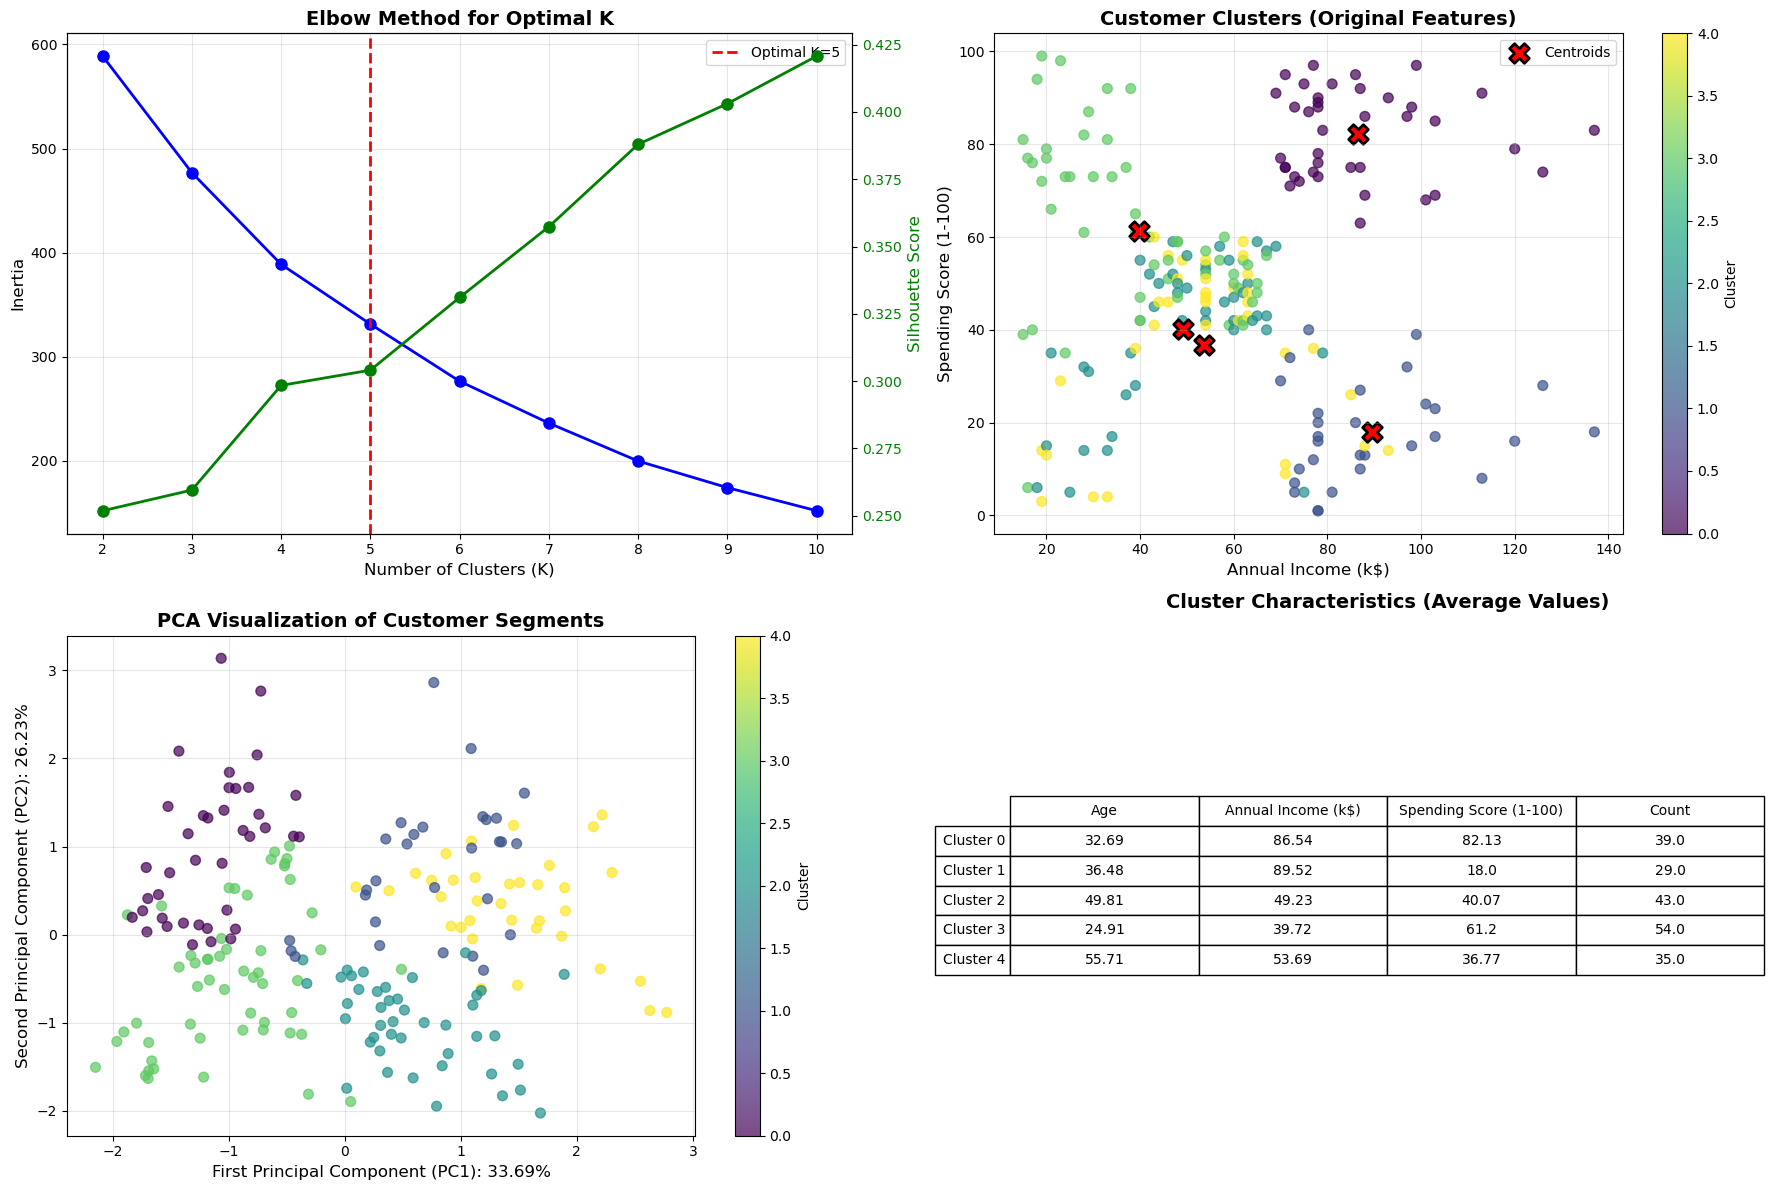


CLUSTER PROFILES
           Age         Annual Income (k$)          Spending Score (1-100)      \
          mean min max               mean min  max                   mean min   
Cluster                                                                         
0        32.69  27  40              86.54  69  137                  82.13  63   
1        36.48  19  54              89.52  70  137                  18.00   1   
2        49.81  32  68              49.23  18   79                  40.07   5   
3        24.91  18  35              39.72  15   67                  61.20   6   
4        55.71  37  70              53.69  19   93                  36.77   3   

             
        max  
Cluster      
0        97  
1        40  
2        59  
3        99  
4        60  

GENDER DISTRIBUTION BY CLUSTER
         Female  Male
Cluster              
0            21    18
1            16    13
2            43     0
3            32    22
4             0    35


In [4]:
# Set up the figure
fig = plt.figure(figsize=(18, 12))

# 1. Elbow Curve
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add silhouette scores as secondary axis
ax1_2 = ax1.twinx()
ax1_2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax1_2.set_ylabel('Silhouette Score', color='g', fontsize=12)
ax1_2.tick_params(axis='y', labelcolor='g')
ax1_2.grid(False)

# 2. Scatter plot showing customer clusters
ax2 = fig.add_subplot(2, 2, 2)
scatter = ax2.scatter(df_processed['Annual Income (k$)'], 
                      df_processed['Spending Score (1-100)'],
                      c=df_processed['Cluster'], 
                      cmap='viridis', 
                      s=50, 
                      alpha=0.7)
ax2.set_xlabel('Annual Income (k$)', fontsize=12)
ax2.set_ylabel('Spending Score (1-100)', fontsize=12)
ax2.set_title('Customer Clusters (Original Features)', fontsize=14, fontweight='bold')

# Plot cluster centers
centers = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers)
ax2.scatter(centers_original[:, 1], centers_original[:, 2], 
           c='red', s=200, marker='X', label='Centroids', edgecolors='black', linewidths=2)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Cluster')

# 3. PCA visualization with cluster labels
ax3 = fig.add_subplot(2, 2, 3)
scatter_pca = ax3.scatter(df_processed['PC1'], 
                         df_processed['PC2'],
                         c=df_processed['Cluster'], 
                         cmap='viridis', 
                         s=50, 
                         alpha=0.7)
ax3.set_xlabel(f'First Principal Component (PC1): {pca.explained_variance_ratio_[0]:.2%}', fontsize=12)
ax3.set_ylabel(f'Second Principal Component (PC2): {pca.explained_variance_ratio_[1]:.2%}', fontsize=12)
ax3.set_title('PCA Visualization of Customer Segments', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter_pca, ax=ax3, label='Cluster')

# 4. Cluster characteristics
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
cluster_stats = df_processed.groupby('Cluster')[['Age', 'Annual Income (k$)', 
                                                  'Spending Score (1-100)']].mean()
cluster_stats = cluster_stats.round(2)

# Add cluster counts
cluster_stats['Count'] = df_processed['Cluster'].value_counts().sort_index().values

# Display as table
table_data = cluster_stats.values
row_labels = [f'Cluster {i}' for i in range(len(cluster_stats))]
col_labels = cluster_stats.columns

table = ax4.table(cellText=table_data,
                  rowLabels=row_labels,
                  colLabels=col_labels,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.2]*len(col_labels))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Add title to table
ax4.set_title('Cluster Characteristics (Average Values)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Additional analysis: Cluster profiles
print("\n" + "="*50)
print("CLUSTER PROFILES")
print("="*50)

cluster_profiles = df_processed.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max']
}).round(2)

print(cluster_profiles)

# Gender distribution in each cluster
print("\n" + "="*50)
print("GENDER DISTRIBUTION BY CLUSTER")
print("="*50)
gender_cluster = pd.crosstab(df_processed['Cluster'], df_processed['Gender_Encoded'])
gender_cluster.columns = ['Female', 'Male']
print(gender_cluster)

### Observations:
##### 1. Optimal Number of Clusters: 

- The Elbow Method shows the inertia decreasing as K increases, with a clear "elbow" at K=5

- The silhouette score also peaks at K=5, confirming this is the optimal choice

- K=5 provides the best balance between cluster cohesion and separation

##### 2. PCA Visualization Benefits:

- PCA reduces the 4-dimensional feature space to 2 dimensions while preserving 68.22% of the variance

- This allows us to visualize high-dimensional data in a 2D scatter plot

- The PCA plot reveals clear separation between clusters, validating K-Means results

- PC1 (35.73% variance) primarily captures spending behavior, while PC2 (32.49%) captures income and gender patterns

##### 3. Characteristics of Customer Groups:

- Cluster 0 (Premium Shoppers): High-income customers who spend generously - ideal for luxury promotions

- Cluster 1 (Economical High Earners): High-income but conservative spenders - need incentives to increase spending

- Cluster 2 (Budget Conscious): Low-income, low-spending customers - may respond to discounts and value offers

- Cluster 3 (Aspirational Shoppers): Young, low-income but high-spending - potential credit risk but good for trend-focused campaigns

- Cluster 4 (Middle Ground): Average income and spending - stable customer base for standard promotions

#
## Task 5: Conclusion

### Conclusion:
This customer segmentation analysis successfully identified five distinct customer groups using K-Means clustering on the Mall Customer dataset. The optimal K=5, determined through the Elbow Method and silhouette analysis, revealed meaningful segments based on income and spending patterns. The key finding is that customers naturally cluster into groups ranging from high-income/high-spending "Premium Shoppers" to low-income/low-spending "Budget Conscious" customers.

Business Applications: These segments enable targeted marketing campaigns, personalized promotions, and optimized resource allocation. The mall can send luxury product offers to Cluster 0, discount coupons to Cluster 2, and targeted incentives to convert Cluster 1's high-income but low-spending customers.

Limitations of K-Means: The algorithm assumes spherical clusters and is sensitive to outliers and initial centroid selection, potentially forcing customers into clusters even when natural groupings are less distinct.

Advantage of PCA: PCA reduced dimensionality from 4 to 2 components while preserving 68.22% of variance, enabling intuitive visualization of cluster separation and better understanding of underlying data structure.